In [ ]:
import seaborn as sns

In [ ]:
df = sns.load_dataset('iris')

In [ ]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
116,6.5,3.0,5.5,1.8,virginica
115,6.4,3.2,5.3,2.3,virginica
82,5.8,2.7,3.9,1.2,versicolor
47,4.6,3.2,1.4,0.2,setosa
67,5.8,2.7,4.1,1.0,versicolor


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:

encoder = LabelEncoder()

In [ ]:
df['species'] = encoder.fit_transform(df['species'])

In [ ]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

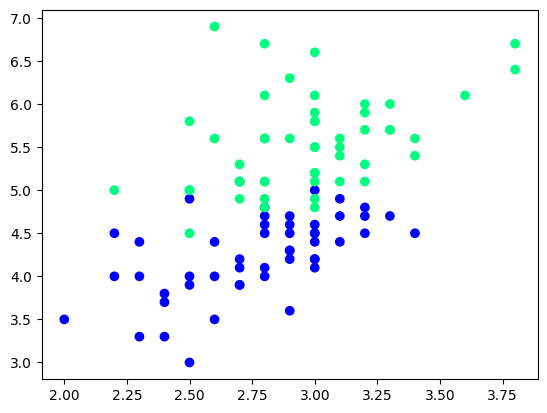

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [ ]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
52,3.1,4.9,1
83,2.7,5.1,1
75,3.0,4.4,1
80,2.4,3.8,1
67,2.7,4.1,1
61,3.0,4.2,1
69,2.5,3.9,1
59,2.7,3.9,1
81,2.4,3.7,1
70,3.2,4.8,1


In [ ]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [ ]:
df_train

,sepal_width,petal_length,species
71,2.8,4.0,1
102,3.0,5.9,2
97,2.9,4.3,1
52,3.1,4.9,1
125,3.2,6.0,2
109,3.6,6.1,2
117,3.8,6.7,2
103,2.9,5.6,2
101,2.7,5.1,2
65,3.1,4.4,1


In [ ]:
df_val

,sepal_width,petal_length,species
84,3.0,4.5,1
82,2.7,3.9,1
63,2.9,4.7,1
132,2.8,5.6,2
98,2.5,3.0,1


In [ ]:

df_test

,sepal_width,petal_length,species
92,2.6,4.0,1
140,3.1,5.6,2
54,2.8,4.6,1
120,3.2,5.7,2
131,3.8,6.4,2


In [ ]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values
y_test

array([1, 1, 1, 2, 1])

Case 1 - Bagging

In [ ]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
65,3.1,4.4,1
65,3.1,4.4,1
71,2.8,4.0,1
103,2.9,5.6,2
117,3.8,6.7,2
109,3.6,6.1,2
102,3.0,5.9,2
97,2.9,4.3,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

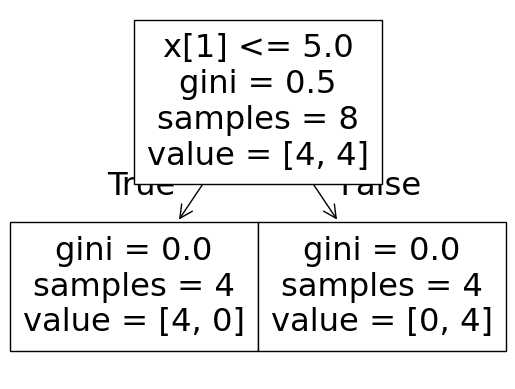

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


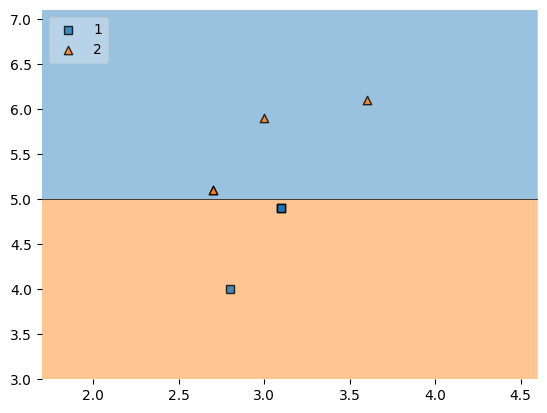

In [ ]:
dt_bag1 = DecisionTreeClassifier()

evaluate(dt_bag1,X,y)

In [ ]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
71,2.8,4.0,1
109,3.6,6.1,2
102,3.0,5.9,2
52,3.1,4.9,1
101,2.7,5.1,2
52,3.1,4.9,1
101,2.7,5.1,2
52,3.1,4.9,1


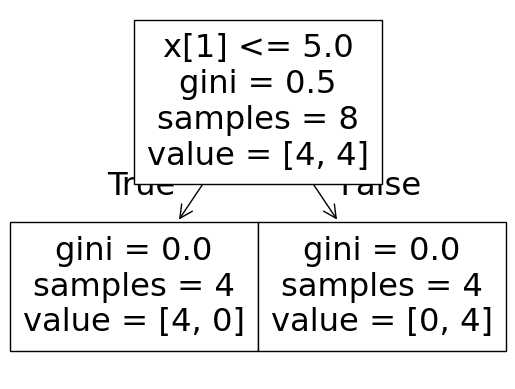

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


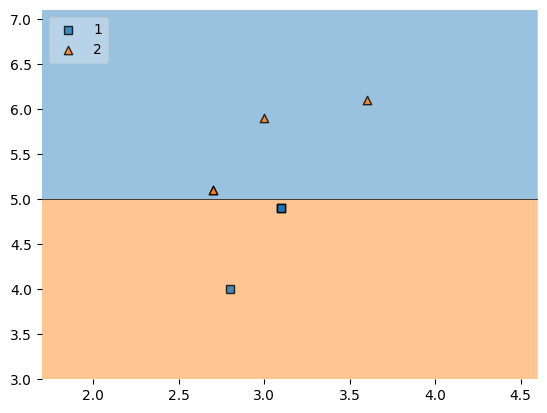

In [ ]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [ ]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
103,2.9,5.6,2
101,2.7,5.1,2
101,2.7,5.1,2
65,3.1,4.4,1
52,3.1,4.9,1
102,3.0,5.9,2
103,2.9,5.6,2
71,2.8,4.0,1


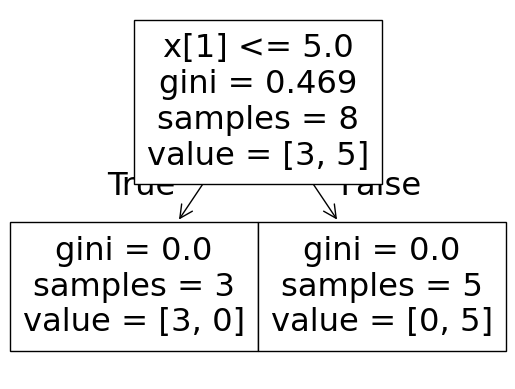

1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


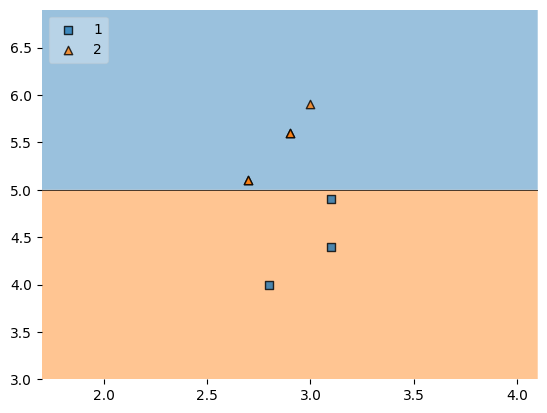

In [ ]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [ ]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))


Predict

In [ ]:
df_test

,sepal_width,petal_length,species
92,2.6,4.0,1
140,3.1,5.6,2
54,2.8,4.6,1
120,3.2,5.7,2
131,3.8,6.4,2


In [ ]:
import numpy as np

In [ ]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Pasting

In [ ]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
71,2.8,4.0,1
102,3.0,5.9,2
97,2.9,4.3,1
52,3.1,4.9,1
125,3.2,6.0,2
109,3.6,6.1,2
117,3.8,6.7,2
103,2.9,5.6,2
101,2.7,5.1,2
65,3.1,4.4,1


In [ ]:

df_train.sample(8)

,sepal_width,petal_length,species
103,2.9,5.6,2
117,3.8,6.7,2
52,3.1,4.9,1
97,2.9,4.3,1
65,3.1,4.4,1
109,3.6,6.1,2
125,3.2,6.0,2
101,2.7,5.1,2


Random Subspaces

In [ ]:
df1 = sns.load_dataset('iris')

In [ ]:
df1.sample(2,replace = True,axis = 1)

,species,sepal_width
0,setosa,3.5
1,setosa,3.0
2,setosa,3.2
3,setosa,3.1
4,setosa,3.6
...,...,...
145,virginica,3.0
146,virginica,2.5
147,virginica,3.0
148,virginica,3.4


Random Patches

In [ ]:
df1.sample(8,replace = True).sample(2,replace = True,axis = 1)

,petal_width,petal_width
17,0.3,0.3
96,1.3,1.3
71,1.3,1.3
60,1.0,1.0
76,1.4,1.4
86,1.5,1.5
63,1.4,1.4
127,1.8,1.8


Bagging Classifiers

In [ ]:

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


In [ ]:

X,y = make_classification(n_samples=10000, n_features=10,n_informative=3)


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)

print("Decision Tree accuracy",accuracy_score(y_test,y_pred))

Decision Tree accuracy 0.8675


Bagging

In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.5,
    bootstrap=True,
    random_state=42
)

In [ ]:
bag.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.5,
                  n_estimators=500, random_state=42)

In [ ]:
y_pred = bag.predict(X_test)

accuracy_score(y_test,y_pred)

0.908

In [ ]:
bag.estimators_samples_[0].shape

(4000,)

In [ ]:
bag.estimators_features_[0].shape

(10,)

Bagging using SVM

In [ ]:
bag = BaggingClassifier(
    estimator=SVC(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    random_state=42
)

In [ ]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Bagging using SVM",accuracy_score(y_test,y_pred))

Bagging using SVM 0.881


Pasting


In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=False,
    random_state=42,
    verbose = 1,
    n_jobs=-1
)

In [ ]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Pasting classifier",accuracy_score(y_test,y_pred))

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   16.3s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Pasting classifier 0.9015


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.4s finished


Random Subspaces

In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=1.0,
    bootstrap=False,
    max_features=0.5,
    bootstrap_features=True,
    random_state=42
)

In [ ]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Random Subspaces classifier",accuracy_score(y_test,y_pred))

Random Subspaces classifier 0.8895


In [ ]:
bag.estimators_samples_[0].shape

(8000,)

In [ ]:
bag.estimators_features_[0].shape

(5,)

Random Patches

In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    max_features=0.5,
    bootstrap_features=True,
    random_state=42
)

In [ ]:
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
print("Random Patches classifier",accuracy_score(y_test,y_pred))

Random Patches classifier 0.8895


OOB Score

In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

In [ ]:
bag.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.25,
                  n_estimators=500, oob_score=True, random_state=42)

In [ ]:
bag.oob_score_

0.908625

In [ ]:
y_pred = bag.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 0.9015


Bagging Tips
* Bagging generally gives
better results than Pasting
* Good results come around the 25% to 50% row sampling mark
* Random patches and subspaces should be used while dealing with high dimensional data
* To find the correct hyperparameter values we can do GridSearchCV/RandomSearchCV

Applying GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
parameters = {
    'n_estimators': [50,100,500],
    'max_samples': [0.1,0.4,0.7,1.0],
    'bootstrap' : [True,False],
    'max_features' : [0.1,0.4,0.7,1.0]
    }


In [ ]:
search = GridSearchCV(BaggingClassifier(), parameters, cv=5)

Random Forest learning tool

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random as random

In [ ]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.738394,2.606869,0.008553,-0.781016,0.160661,0
1,0.654352,-0.182125,-0.068160,0.734974,-1.663900,1
2,0.040042,1.560361,1.375545,0.914204,-0.741406,0
3,2.754925,-0.461304,0.962362,2.379517,-0.904441,0
4,3.452941,-2.793047,3.084480,2.529888,1.299796,1


In [ ]:
#function for row sampling

def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [ ]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [ ]:
# function for combined sampling
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [ ]:
df1 = combined_sampling(df,0.2,0.8)
df1.head()

/tmp/ipykernel_1811/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col2,col4,col1,col3,target
30,-1.642458,-1.472357,1.034494,-0.623279,1
71,-0.779846,1.327287,0.718638,1.170004,1
38,-0.330123,2.341333,4.032293,0.730477,0
60,-0.187067,-0.991664,-0.628172,-0.973044,1
21,-0.241720,-0.113328,0.200707,-0.525059,1


In [ ]:
df2 = combined_sampling(df,0.5,0.5)
df2.head()


/tmp/ipykernel_1811/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col4,col1,target
0,-0.781016,0.738394,0
6,0.786909,1.898904,1
31,1.369347,0.239705,0
78,1.015882,0.909588,1
22,1.606647,-0.040866,0


In [ ]:
df3 = combined_sampling(df,0.8,0.2)
df3.head()

/tmp/ipykernel_1811/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col4,target
51,0.481431,1
20,1.551123,0
38,2.341333,0
24,0.557896,0
32,1.922455,1


In [ ]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col4', 'col1', 'col3', 'target'], dtype='object')
Index(['col4', 'col1', 'target'], dtype='object')
Index(['col4', 'target'], dtype='object')


In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:1],df3.iloc[:,-1])


DecisionTreeClassifier()

In [ ]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[0] <= 0.062\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.4, 0.5, 'x[1] <= 2.132\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

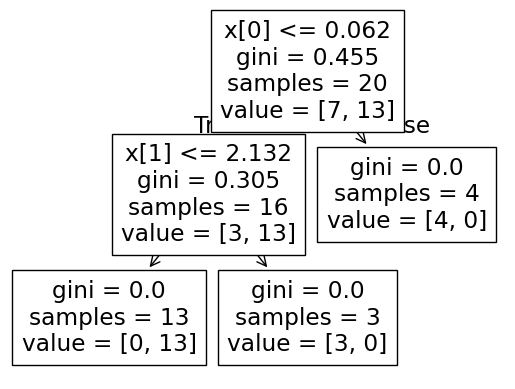

In [ ]:
plot_tree(clf1)

[Text(0.5625, 0.95, 'x[0] <= 0.81\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.25, 0.85, 'x[1] <= -1.115\ngini = 0.397\nsamples = 22\nvalue = [6, 16]'),
 Text(0.40625, 0.8999999999999999, 'True  '),
 Text(0.1875, 0.75, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3125, 0.75, 'x[0] <= -0.725\ngini = 0.266\nsamples = 19\nvalue = [3, 16]'),
 Text(0.125, 0.65, 'x[1] <= -0.084\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.0625, 0.55, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.1875, 0.55, 'x[0] <= -1.404\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.125, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.45, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5, 0.65, 'x[1] <= -0.007\ngini = 0.133\nsamples = 14\nvalue = [1, 13]'),
 Text(0.4375, 0.55, 'x[1] <= -0.19\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.375, 0.45, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.5, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text

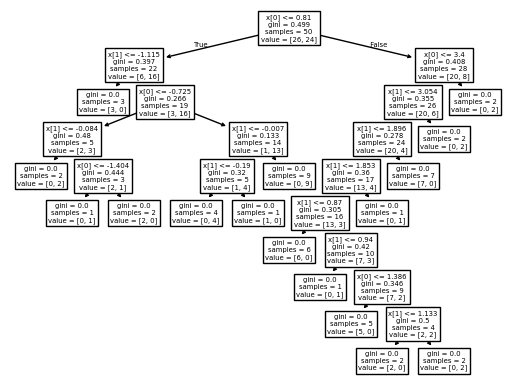

In [ ]:
plot_tree(clf2)

[Text(0.6136363636363636, 0.9545454545454546, 'x[0] <= 0.851\ngini = 0.492\nsamples = 80\nvalue = [35, 45]'),
 Text(0.45454545454545453, 0.8636363636363636, 'x[0] <= -1.312\ngini = 0.414\nsamples = 41\nvalue = [12, 29]'),
 Text(0.5340909090909091, 0.9090909090909092, 'True  '),
 Text(0.4090909090909091, 0.7727272727272727, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.5, 0.7727272727272727, 'x[0] <= 0.68\ngini = 0.361\nsamples = 38\nvalue = [9, 29]'),
 Text(0.45454545454545453, 0.6818181818181818, 'x[0] <= 0.52\ngini = 0.389\nsamples = 34\nvalue = [9, 25]'),
 Text(0.36363636363636365, 0.5909090909090909, 'x[0] <= 0.17\ngini = 0.302\nsamples = 27\nvalue = [5, 22]'),
 Text(0.3181818181818182, 0.5, 'x[0] <= -0.057\ngini = 0.415\nsamples = 17\nvalue = [5, 12]'),
 Text(0.2727272727272727, 0.4090909090909091, 'x[0] <= -0.284\ngini = 0.32\nsamples = 15\nvalue = [3, 12]'),
 Text(0.22727272727272727, 0.3181818181818182, 'x[0] <= -1.006\ngini = 0.397\nsamples = 11\nvalue = [3, 8]'),
 Text(

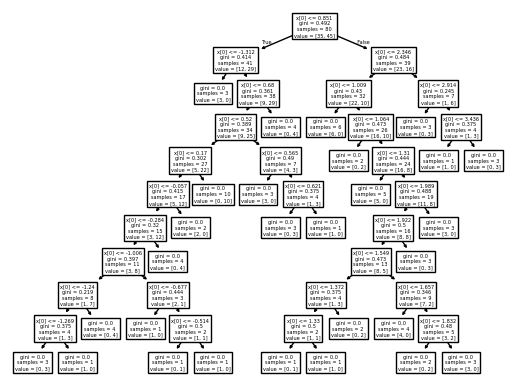

In [ ]:
plot_tree(clf3)

In [ ]:
clf1.predict(np.array([1.521171,	-0.750832,	-0.024089,	0.527833]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
clf2.predict(np.array([1.521171,	-0.750832]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
clf3.predict(np.array([1.521171]).reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

Random Forest demo

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X.shape

(500, 2)

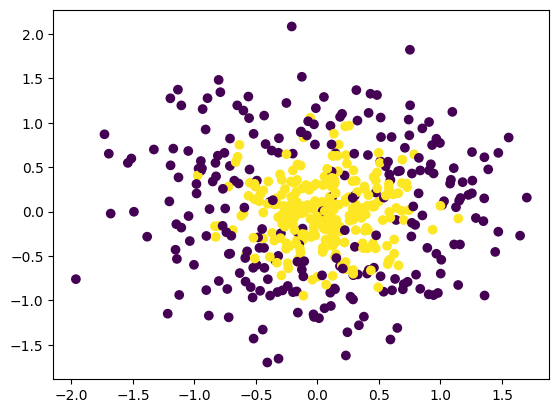

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y)

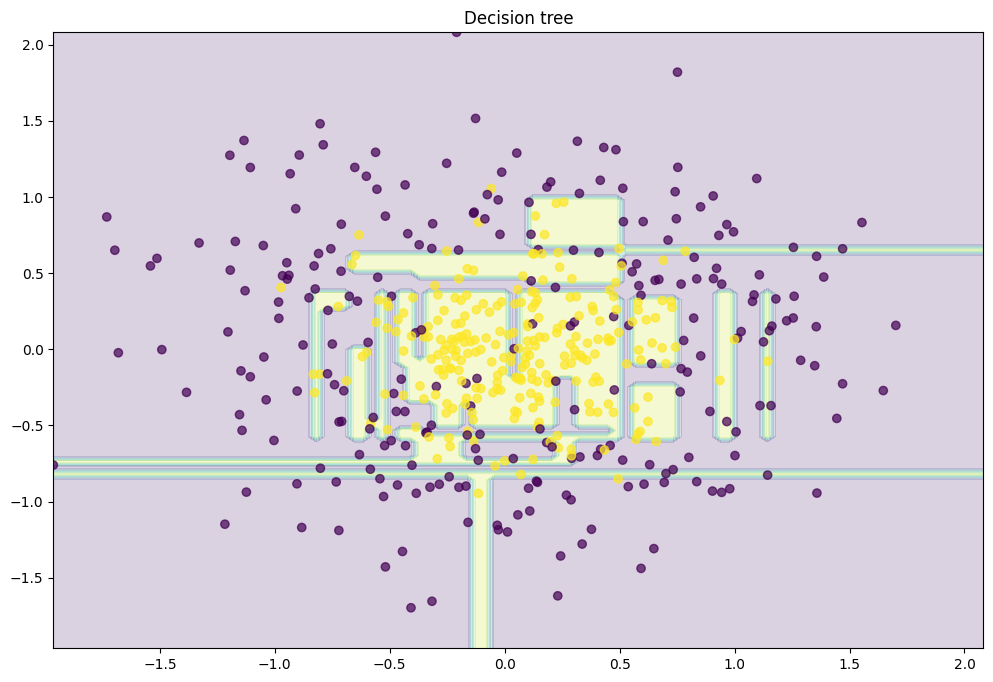

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

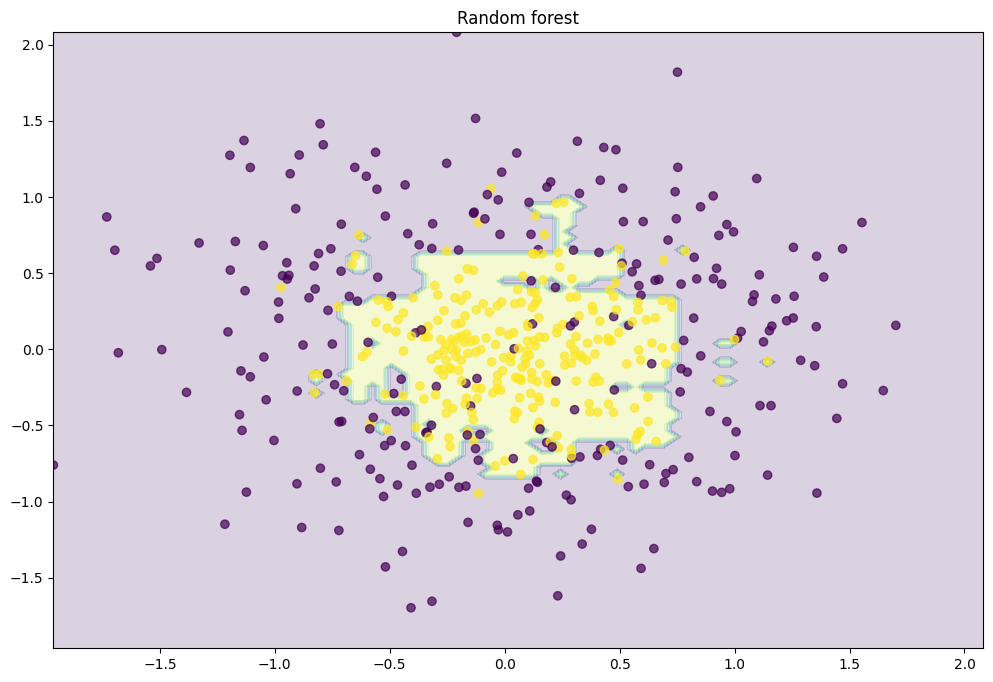

In [ ]:
rf = RandomForestClassifier(n_estimators = 500, random_state = 42)
rf.fit(X_train,y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

In [ ]:
n_train = 150
n_test = 1000
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

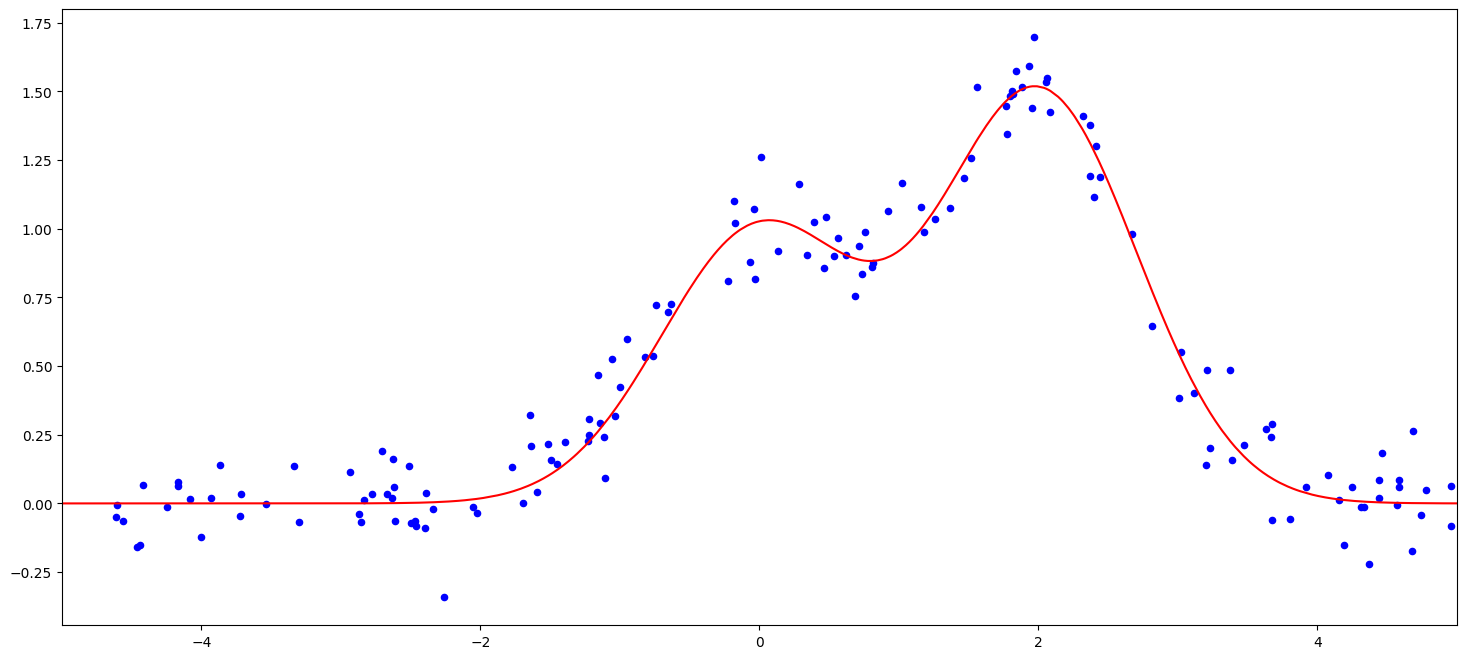

In [ ]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])

Text(0.5, 1.0, 'Decision tree, MSE = 22.70')

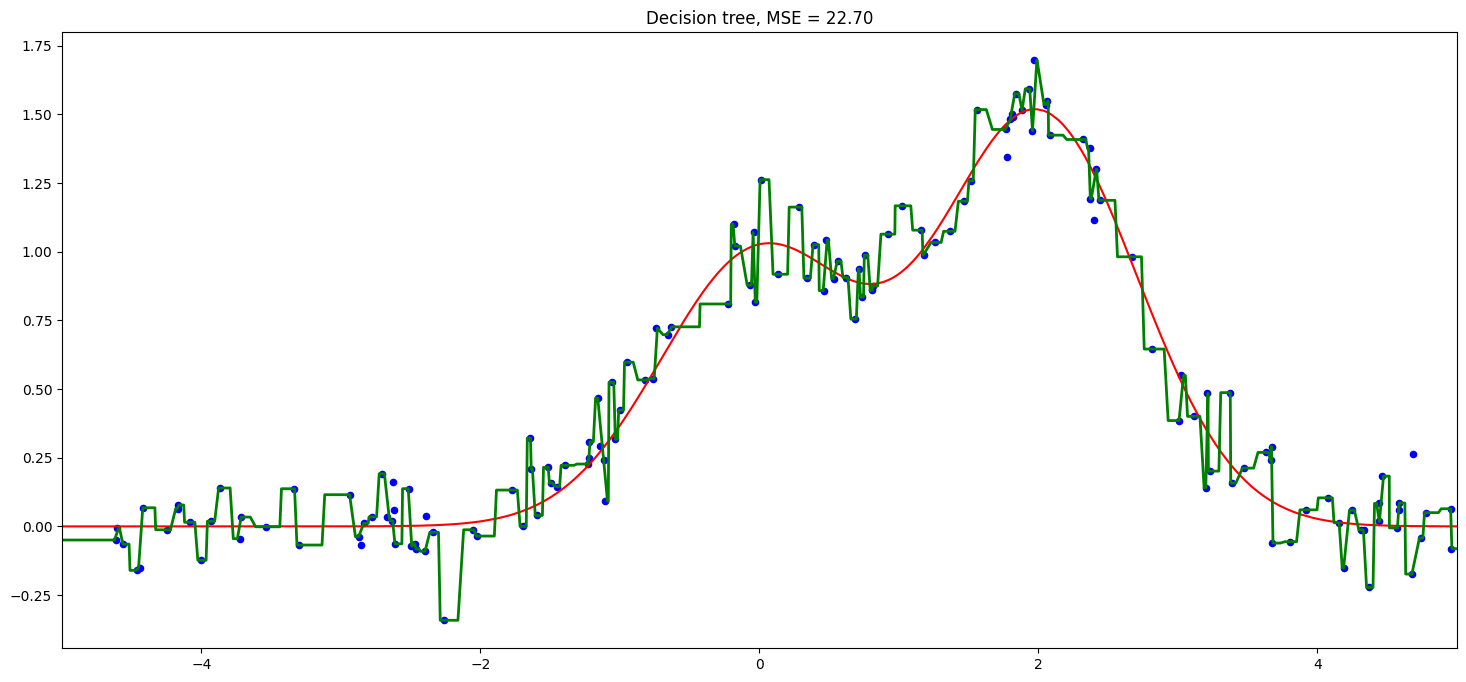

In [ ]:
# One decision tree regressor
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f"
          % np.sum((y_test - d_predict) ** 2))

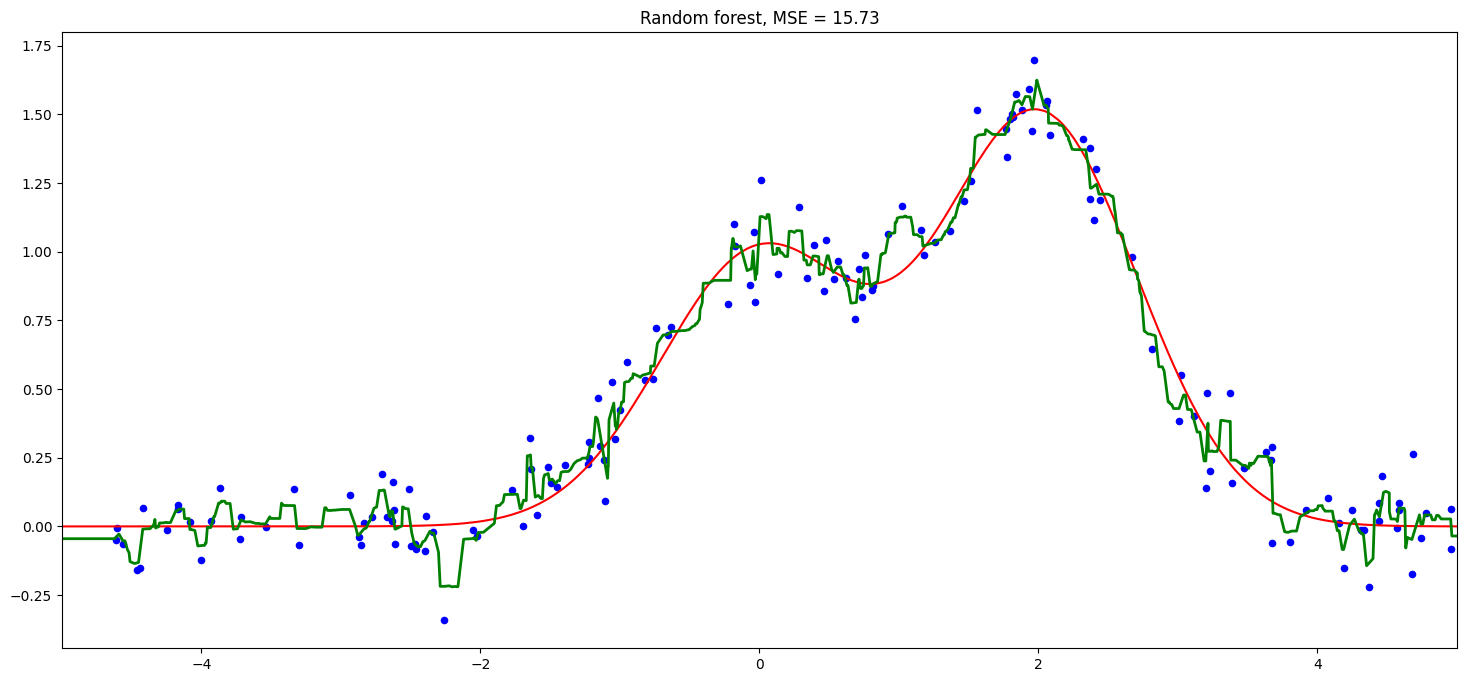

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));

Feature Importance using Random Forest and Decision Trees


In [ ]:
import pandas as pd
import seaborn as sns

(1797, 65)


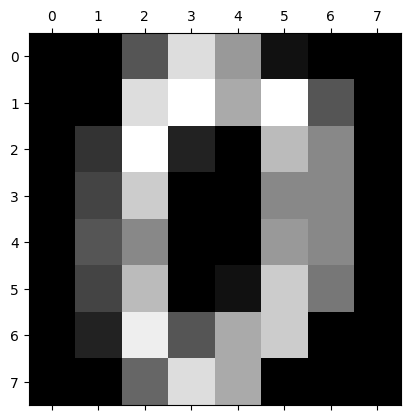

In [ ]:
from sklearn.datasets import load_digits
import pandas as pd # Ensure pandas is imported
import matplotlib.pyplot as plt

# Load the digits dataset
digits_bunch = load_digits()

# Create a DataFrame from the data (features) and add the target column
df = pd.DataFrame(digits_bunch.data)
df['target'] = digits_bunch.target

# Print the shape of the created DataFrame
print(df.shape)

# Plot the first image using the original images array from the Bunch object
plt.matshow(digits_bunch.images[0], cmap="gray")
plt.show()

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

<Axes: >

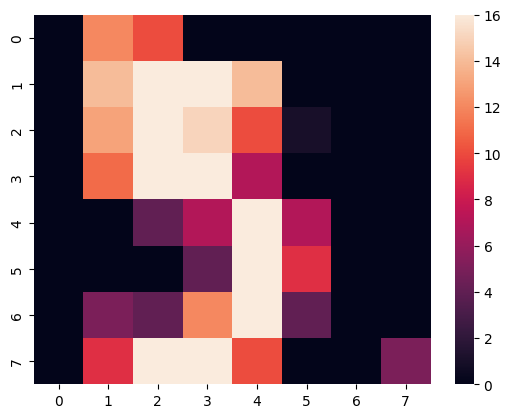

In [ ]:
sns.heatmap(X.iloc[5].values.reshape(8,8))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

X.columns = X.columns.astype(str) # Convert column names to strings to resolve TypeError

rf.fit(X,y)

RandomForestClassifier()

In [ ]:
rf.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
rf.feature_importances_.shape

(64,)

<Axes: >

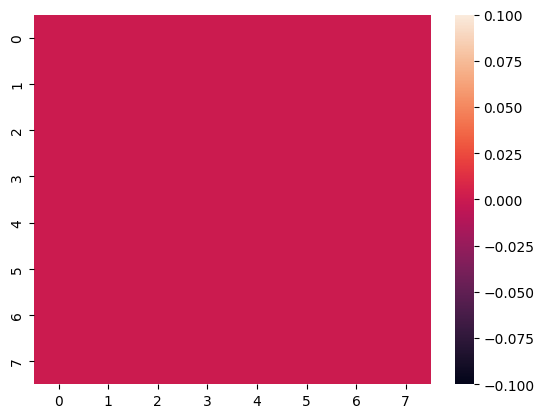

In [ ]:
sns.heatmap(rf.feature_importances_.reshape(8,8))

How feature importance is calculated

In [ ]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

In [ ]:
X,y = make_classification(n_samples=5, n_classes=2,
                               n_features=2, n_informative=2, n_redundant=0,
                               random_state=0)

In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.894\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 1.01\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

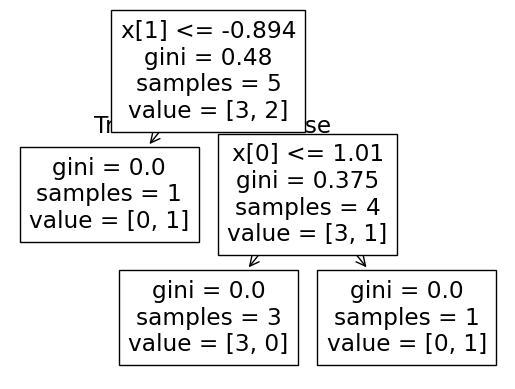

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [ ]:
clf.feature_importances_

array([0.625, 0.375])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=2)
rf.fit(X,y)

RandomForestClassifier(n_estimators=2)

In [ ]:
rf.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=753730788),
 DecisionTreeClassifier(max_features='sqrt', random_state=43586949)]

In [ ]:
rf.feature_importances_

array([0.37850765, 0.62149235])

In [ ]:
print(rf.estimators_[0].feature_importances_)
print(rf.estimators_[1].feature_importances_)

print((0 + 0.757)/2)

[0. 1.]
[0.75701531 0.24298469]
0.3785


In [ ]:
X,y = make_classification(n_samples=15, n_classes=2,
                               n_features=2, n_informative=2, n_redundant=0,
                               random_state=0)
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.3333333333333333, 0.875, 'x[1] <= -0.383\ngini = 0.498\nsamples = 15\nvalue = [8, 7]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[0] <= 0.878\ngini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.6666666666666666, 0.375, 'x[1] <= -0.278\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]')]

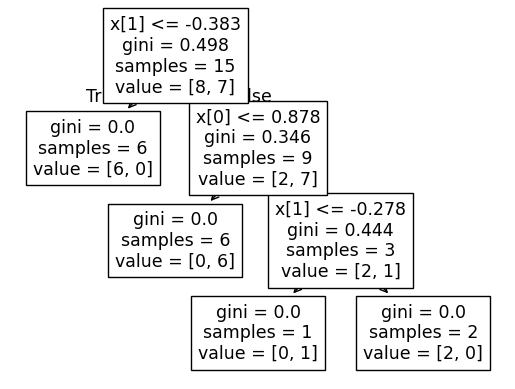

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [ ]:
clf.feature_importances_

array([0.23809524, 0.76190476])